In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [15]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews",
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

In [16]:
train_data
print("GPU is", "available" if tf.config.experimental.list_physical_devices("GPU") else "NOT AVAILABLE")

GPU is NOT AVAILABLE


In [17]:
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=20000,
    output_mode='int',
    output_sequence_length=300
)

In [18]:
train_text = train_data.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [19]:
def vectorize_text(text, label):
    return vectorize_layer(text), label

In [20]:
import os

glove_path = "glove.6B.100d.txt"
if not os.path.exists(glove_path):
    raise FileNotFoundError("Download GloVe and place it in project folder")

In [21]:
import numpy as np

embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Get vocab
vocab = vectorize_layer.get_vocabulary()
print("Vocab size:", len(vocab))
word_index = dict(zip(vocab, range(len(vocab))))

embedding_dim = 100
embedding_matrix = np.zeros((len(vocab), embedding_dim))

for word, i in word_index.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

Vocab size: 20000


In [22]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=len(vocab),
        output_dim=100,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True   
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    ),

    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [25]:
batch_size = 32

train_data = train_data.map(vectorize_text)
validation_data = validation_data.map(vectorize_text)
test_data = test_data.map(vectorize_text)

train_data = train_data.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
validation_data = validation_data.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [26]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10



469/469 [==============================] - 73s 142ms/step - loss: 0.5842 - accuracy: 0.6864 - val_loss: 0.4907 - val_accuracy: 0.7625
Epoch 2/10
469/469 [==============================] - 70s 146ms/step - loss: 0.4482 - accuracy: 0.7970 - val_loss: 0.4314 - val_accuracy: 0.8002
Epoch 3/10
469/469 [==============================] - 90s 188ms/step - loss: 0.3973 - accuracy: 0.8239 - val_loss: 0.3821 - val_accuracy: 0.8283
Epoch 4/10
469/469 [==============================] - 105s 221ms/step - loss: 0.3621 - accuracy: 0.8429 - val_loss: 0.3670 - val_accuracy: 0.8388
Epoch 5/10
469/469 [==============================] - 104s 219ms/step - loss: 0.3340 - accuracy: 0.8584 - val_loss: 0.3479 - val_accuracy: 0.8486
Epoch 6/10
469/469 [==============================] - 102s 215ms/step - loss: 0.3164 - accuracy: 0.8651 - val_loss: 0.3600 - val_accuracy: 0.8384
Epoch 7/10
469/469 [==============================] - 101s 214ms/step - loss: 0.2933 - accuracy: 0.8771 - val_loss: 0.3295 - val_accuracy:

In [27]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

782/782 [==============================] - 54s 69ms/step - loss: 0.3243 - accuracy: 0.8568
Test Accuracy: 0.8568000197410583


In [28]:
import matplotlib.pyplot as plt

In [29]:
import os
os.makedirs('results', exist_ok=True)

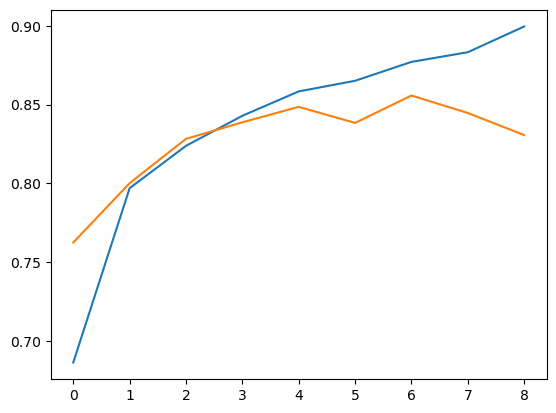

In [30]:
import os
import matplotlib.pyplot as plt

os.makedirs('results', exist_ok=True)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.savefig('results/accuracy.png')
plt.show()

In [44]:
import numpy as np

y_pred_prob = model.predict(validation_data, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = np.concatenate([y.numpy() for x, y in validation_data])

313/313 [==============================] - 20s 65ms/step


In [45]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy: 0.8558

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4990
           1       0.84      0.87      0.86      5010

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



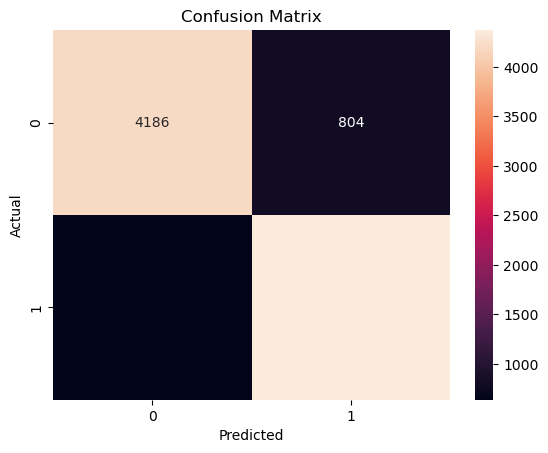

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save results
os.makedirs("results", exist_ok=True)
plt.savefig("results/confusion_matrix.png")

plt.show()

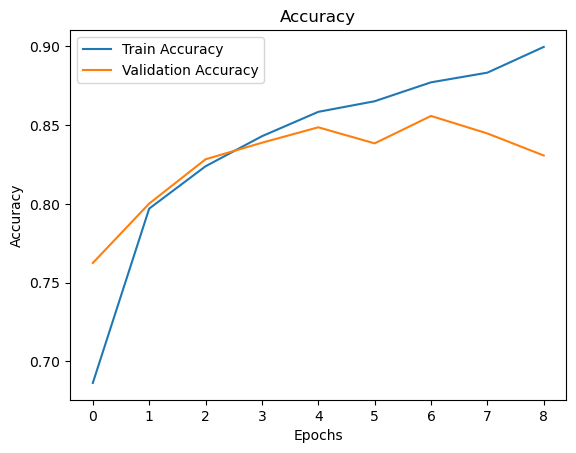

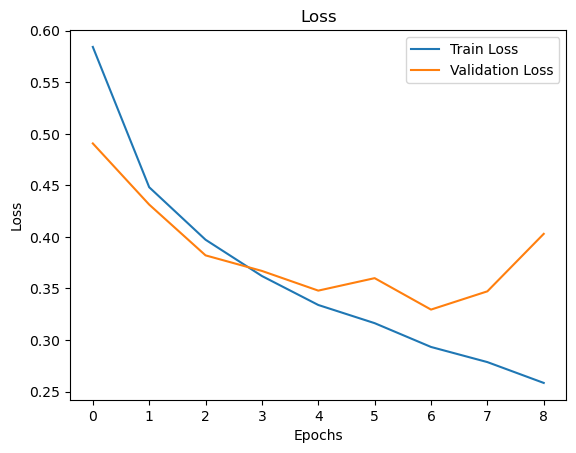

In [47]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.savefig("results/accuracy.png")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.savefig("results/loss.png")
plt.show()

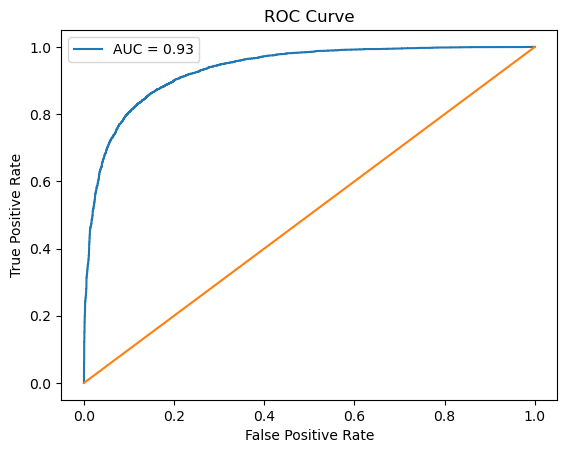

In [48]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob.flatten())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("results/roc_curve.png")
plt.show()